# ⚖️ TÉCNICAS AVANZADAS DE BALANCEO
## Mitigando el Desbalanceo Extremo del Dataset

Este notebook compara diferentes técnicas para manejar datasets desbalanceados:
- **SMOTE** (Synthetic Minority Over-sampling)
- **ADASYN** (Adaptive Synthetic Sampling)
- **SMOTETomek** (SMOTE + Tomek Links)
- **RandomUnderSampler** (Submuestreo)
- **Ensemble con BalancedRandomForest**
- **XGBoost con scale_pos_weight**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from collections import Counter

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
# Cargar datos preprocesados
print("📁 Cargando datos...\n")

with open('../data/preprocessed_data.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Datos ORIGINALES (sin balancear)
X_train_orig, X_test, y_train_orig, y_test = datasets['original']

print(f"✅ Datos cargados")
print(f"\n📊 Train set original (sin balancear):")
print(f"   Total: {len(y_train_orig)} muestras")
print(f"   Sin ictus: {(y_train_orig == 0).sum()} ({(y_train_orig == 0).sum()/len(y_train_orig)*100:.1f}%)")
print(f"   Con ictus: {(y_train_orig == 1).sum()} ({(y_train_orig == 1).sum()/len(y_train_orig)*100:.1f}%)")
print(f"   Ratio: {(y_train_orig == 0).sum() / (y_train_orig == 1).sum():.1f}:1")

print(f"\n📊 Test set:")
print(f"   Total: {len(y_test)} muestras")
print(f"   Sin ictus: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   Con ictus: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")
print(f"   Ratio: {(y_test == 0).sum() / (y_test == 1).sum():.1f}:1")

📁 Cargando datos...

✅ Datos cargados

📊 Train set original (sin balancear):
   Total: 3984 muestras
   Sin ictus: 3786 (95.0%)
   Con ictus: 198 (5.0%)
   Ratio: 19.1:1

📊 Test set:
   Total: 997 muestras
   Sin ictus: 947 (95.0%)
   Con ictus: 50 (5.0%)
   Ratio: 18.9:1


In [3]:
# Función auxiliar para evaluar modelos
def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Evalúa un modelo y retorna métricas"""
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean = np.sqrt(recall * specificity)
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'specificity': specificity,
        'g_mean': g_mean,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }

print("✅ Función de evaluación definida")

✅ Función de evaluación definida


In [4]:
# Definir estrategias de balanceo
print("\n" + "="*80)
print("🔬 PROBANDO DIFERENTES TÉCNICAS DE BALANCEO")
print("="*80)

balancing_strategies = {
    'Original (Sin balanceo)': None,
    'SMOTE': SMOTE(random_state=42, k_neighbors=5),
    'ADASYN': ADASYN(random_state=42, n_neighbors=5),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42, k_neighbors=5),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42)
}

results_list = []

for strategy_name, sampler in balancing_strategies.items():
    print(f"\n{'='*60}")
    print(f"🔄 Probando: {strategy_name}")
    print(f"{'='*60}")
    
    # Aplicar balanceo
    if sampler is None:
        X_train_balanced = X_train_orig
        y_train_balanced = y_train_orig
    else:
        try:
            X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_orig, y_train_orig)
        except Exception as e:
            print(f"❌ Error con {strategy_name}: {e}")
            continue
    
    print(f"\n📊 Distribución después de balanceo:")
    print(f"   Total: {len(y_train_balanced)} muestras")
    print(f"   Sin ictus: {(y_train_balanced == 0).sum()}")
    print(f"   Con ictus: {(y_train_balanced == 1).sum()}")
    print(f"   Ratio: {(y_train_balanced == 0).sum() / (y_train_balanced == 1).sum():.2f}:1")
    
    # Entrenar XGBoost
    print(f"\n🚀 Entrenando XGBoost...")
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predecir
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluar
    metrics = evaluate_model(y_test, y_pred, y_proba, strategy_name)
    results_list.append(metrics)
    
    print(f"\n📊 Resultados:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1-Score:  {metrics['f1']:.4f}")
    print(f"   ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"   G-Mean:    {metrics['g_mean']:.4f}")
    print(f"   FP: {metrics['fp']}, FN: {metrics['fn']}")

print("\n✅ Análisis de balanceo completado")


🔬 PROBANDO DIFERENTES TÉCNICAS DE BALANCEO

🔄 Probando: Original (Sin balanceo)

📊 Distribución después de balanceo:
   Total: 3984 muestras
   Sin ictus: 3786
   Con ictus: 198
   Ratio: 19.12:1

🚀 Entrenando XGBoost...

📊 Resultados:
   Accuracy:  0.9498
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000
   ROC-AUC:   0.8379
   G-Mean:    0.0000
   FP: 0, FN: 50

🔄 Probando: SMOTE

📊 Distribución después de balanceo:
   Total: 7572 muestras
   Sin ictus: 3786
   Con ictus: 3786
   Ratio: 1.00:1

🚀 Entrenando XGBoost...

📊 Resultados:
   Accuracy:  0.8766
   Precision: 0.1456
   Recall:    0.3000
   F1-Score:  0.1961
   ROC-AUC:   0.8096
   G-Mean:    0.5217
   FP: 88, FN: 35

🔄 Probando: ADASYN

📊 Distribución después de balanceo:
   Total: 7606 muestras
   Sin ictus: 3786
   Con ictus: 3820
   Ratio: 0.99:1

🚀 Entrenando XGBoost...

📊 Resultados:
   Accuracy:  0.9498
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000
   ROC-AUC:   0.8379
   G-Mean:    0.0000

In [5]:
# Probar XGBoost con scale_pos_weight
print("\n" + "="*80)
print("🔬 PROBANDO XGBOOST CON SCALE_POS_WEIGHT")
print("="*80)

# Calcular scale_pos_weight óptimo
scale_pos_weight = (y_train_orig == 0).sum() / (y_train_orig == 1).sum()
print(f"\nScale pos weight calculado: {scale_pos_weight:.2f}")

weight_values = [
    1,  # Sin peso
    scale_pos_weight / 2,  # Mitad del ratio
    scale_pos_weight,  # Ratio exacto
    scale_pos_weight * 1.5,  # 1.5x el ratio
    scale_pos_weight * 2  # 2x el ratio
]

for weight in weight_values:
    print(f"\n{'='*60}")
    print(f"🔄 scale_pos_weight = {weight:.2f}")
    print(f"{'='*60}")
    
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train_orig, y_train_orig)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, f'XGBoost (weight={weight:.2f})')
    results_list.append(metrics)
    
    print(f"\n📊 Resultados:")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1-Score:  {metrics['f1']:.4f}")
    print(f"   ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"   G-Mean:    {metrics['g_mean']:.4f}")

print("\n✅ Análisis con scale_pos_weight completado")


🔬 PROBANDO XGBOOST CON SCALE_POS_WEIGHT

Scale pos weight calculado: 19.12

🔄 scale_pos_weight = 1.00

📊 Resultados:
   Accuracy:  0.9498
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000
   ROC-AUC:   0.8379
   G-Mean:    0.0000

🔄 scale_pos_weight = 9.56

📊 Resultados:
   Accuracy:  0.8917
   Precision: 0.1628
   Recall:    0.2800
   F1-Score:  0.2059
   ROC-AUC:   0.8347
   G-Mean:    0.5086

🔄 scale_pos_weight = 19.12

📊 Resultados:
   Accuracy:  0.8917
   Precision: 0.1628
   Recall:    0.2800
   F1-Score:  0.2059
   ROC-AUC:   0.8347
   G-Mean:    0.5086

🔄 scale_pos_weight = 19.12

📊 Resultados:
   Accuracy:  0.8586
   Precision: 0.1773
   Recall:    0.5000
   F1-Score:  0.2618
   ROC-AUC:   0.8301
   G-Mean:    0.6624

🔄 scale_pos_weight = 28.68

📊 Resultados:
   Accuracy:  0.8586
   Precision: 0.1773
   Recall:    0.5000
   F1-Score:  0.2618
   ROC-AUC:   0.8301
   G-Mean:    0.6624

🔄 scale_pos_weight = 28.68

📊 Resultados:
   Accuracy:  0.8355
   Precision: 0.1

In [6]:
# Probar BalancedRandomForest
print("\n" + "="*80)
print("🔬 PROBANDO BALANCED RANDOM FOREST")
print("="*80)

model_brf = BalancedRandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

print("\n🚀 Entrenando Balanced Random Forest...")
model_brf.fit(X_train_orig, y_train_orig)

y_pred_brf = model_brf.predict(X_test)
y_proba_brf = model_brf.predict_proba(X_test)[:, 1]

metrics_brf = evaluate_model(y_test, y_pred_brf, y_proba_brf, 'BalancedRandomForest')
results_list.append(metrics_brf)

print(f"\n📊 Resultados:")
print(f"   Accuracy:  {metrics_brf['accuracy']:.4f}")
print(f"   Precision: {metrics_brf['precision']:.4f}")
print(f"   Recall:    {metrics_brf['recall']:.4f}")
print(f"   F1-Score:  {metrics_brf['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_brf['roc_auc']:.4f}")
print(f"   G-Mean:    {metrics_brf['g_mean']:.4f}")

print("\n✅ Balanced Random Forest completado")


🔬 PROBANDO BALANCED RANDOM FOREST

🚀 Entrenando Balanced Random Forest...

📊 Resultados:
   Accuracy:  0.7703
   Precision: 0.1490
   Recall:    0.7600
   F1-Score:  0.2492
   ROC-AUC:   0.8375
   G-Mean:    0.7654

✅ Balanced Random Forest completado

📊 Resultados:
   Accuracy:  0.7703
   Precision: 0.1490
   Recall:    0.7600
   F1-Score:  0.2492
   ROC-AUC:   0.8375
   G-Mean:    0.7654

✅ Balanced Random Forest completado


In [ ]:
# Crear DataFrame de resultados
results_df = pd.DataFrame(results_list)

print("\n" + "="*100)
print("📊 COMPARACIÓN COMPLETA DE ESTRATEGIAS")
print("="*100)

display_df = results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'g_mean', 'fn', 'fp']].copy()
display_df = display_df.sort_values('f1', ascending=False)
display_df = display_df.round(4)

print("\n" + display_df.to_string(index=False))

# Identificar mejores modelos
print("\n" + "="*100)
print("🏆 MEJORES MODELOS")
print("="*100)

best_f1 = results_df.loc[results_df['f1'].idxmax()]
best_recall = results_df.loc[results_df['recall'].idxmax()]
best_gmean = results_df.loc[results_df['g_mean'].idxmax()]
best_roc = results_df.loc[results_df['roc_auc'].idxmax()]

print(f"\n🥇 Mejor F1-Score: {best_f1['model']}")
print(f"   F1: {best_f1['f1']:.4f} | Recall: {best_f1['recall']:.4f} | Precision: {best_f1['precision']:.4f}")

print(f"\n🥇 Mejor Recall: {best_recall['model']}")
print(f"   Recall: {best_recall['recall']:.4f} | F1: {best_recall['f1']:.4f} | Precision: {best_recall['precision']:.4f}")

print(f"\n🥇 Mejor G-Mean: {best_gmean['model']}")
print(f"   G-Mean: {best_gmean['g_mean']:.4f} | Recall: {best_gmean['recall']:.4f} | Specificity: {best_gmean['specificity']:.4f}")

print(f"\n🥇 Mejor ROC-AUC: {best_roc['model']}")
print(f"   ROC-AUC: {best_roc['roc_auc']:.4f} | F1: {best_roc['f1']:.4f}")


📊 COMPARACIÓN COMPLETA DE ESTRATEGIAS

                  model  accuracy  precision  recall     f1  roc_auc  g_mean  fn  fp
 XGBoost (weight=19.12)    0.8586     0.1773    0.50 0.2618   0.8301  0.6624  25 116
 XGBoost (weight=28.68)    0.8355     0.1647    0.56 0.2545   0.8236  0.6899  22 142
 XGBoost (weight=38.24)    0.8164     0.1590    0.62 0.2531   0.8305  0.7160  19 164
   BalancedRandomForest    0.7703     0.1490    0.76 0.2492   0.8375  0.7654  12 217
               SMOTEENN    0.8164     0.1481    0.56 0.2343   0.8296  0.6818  22 161
     RandomUnderSampler    0.7101     0.1346    0.88 0.2334   0.8245  0.7855   6 283
                 ADASYN    0.8686     0.1478    0.34 0.2061   0.8064  0.5521  33  98
  XGBoost (weight=9.56)    0.8917     0.1628    0.28 0.2059   0.8347  0.5086  36  72
                  SMOTE    0.8766     0.1456    0.30 0.1961   0.8096  0.5217  35  88
        BorderlineSMOTE    0.8957     0.1538    0.24 0.1875   0.8204  0.4725  38  66
             SMOTETomek  

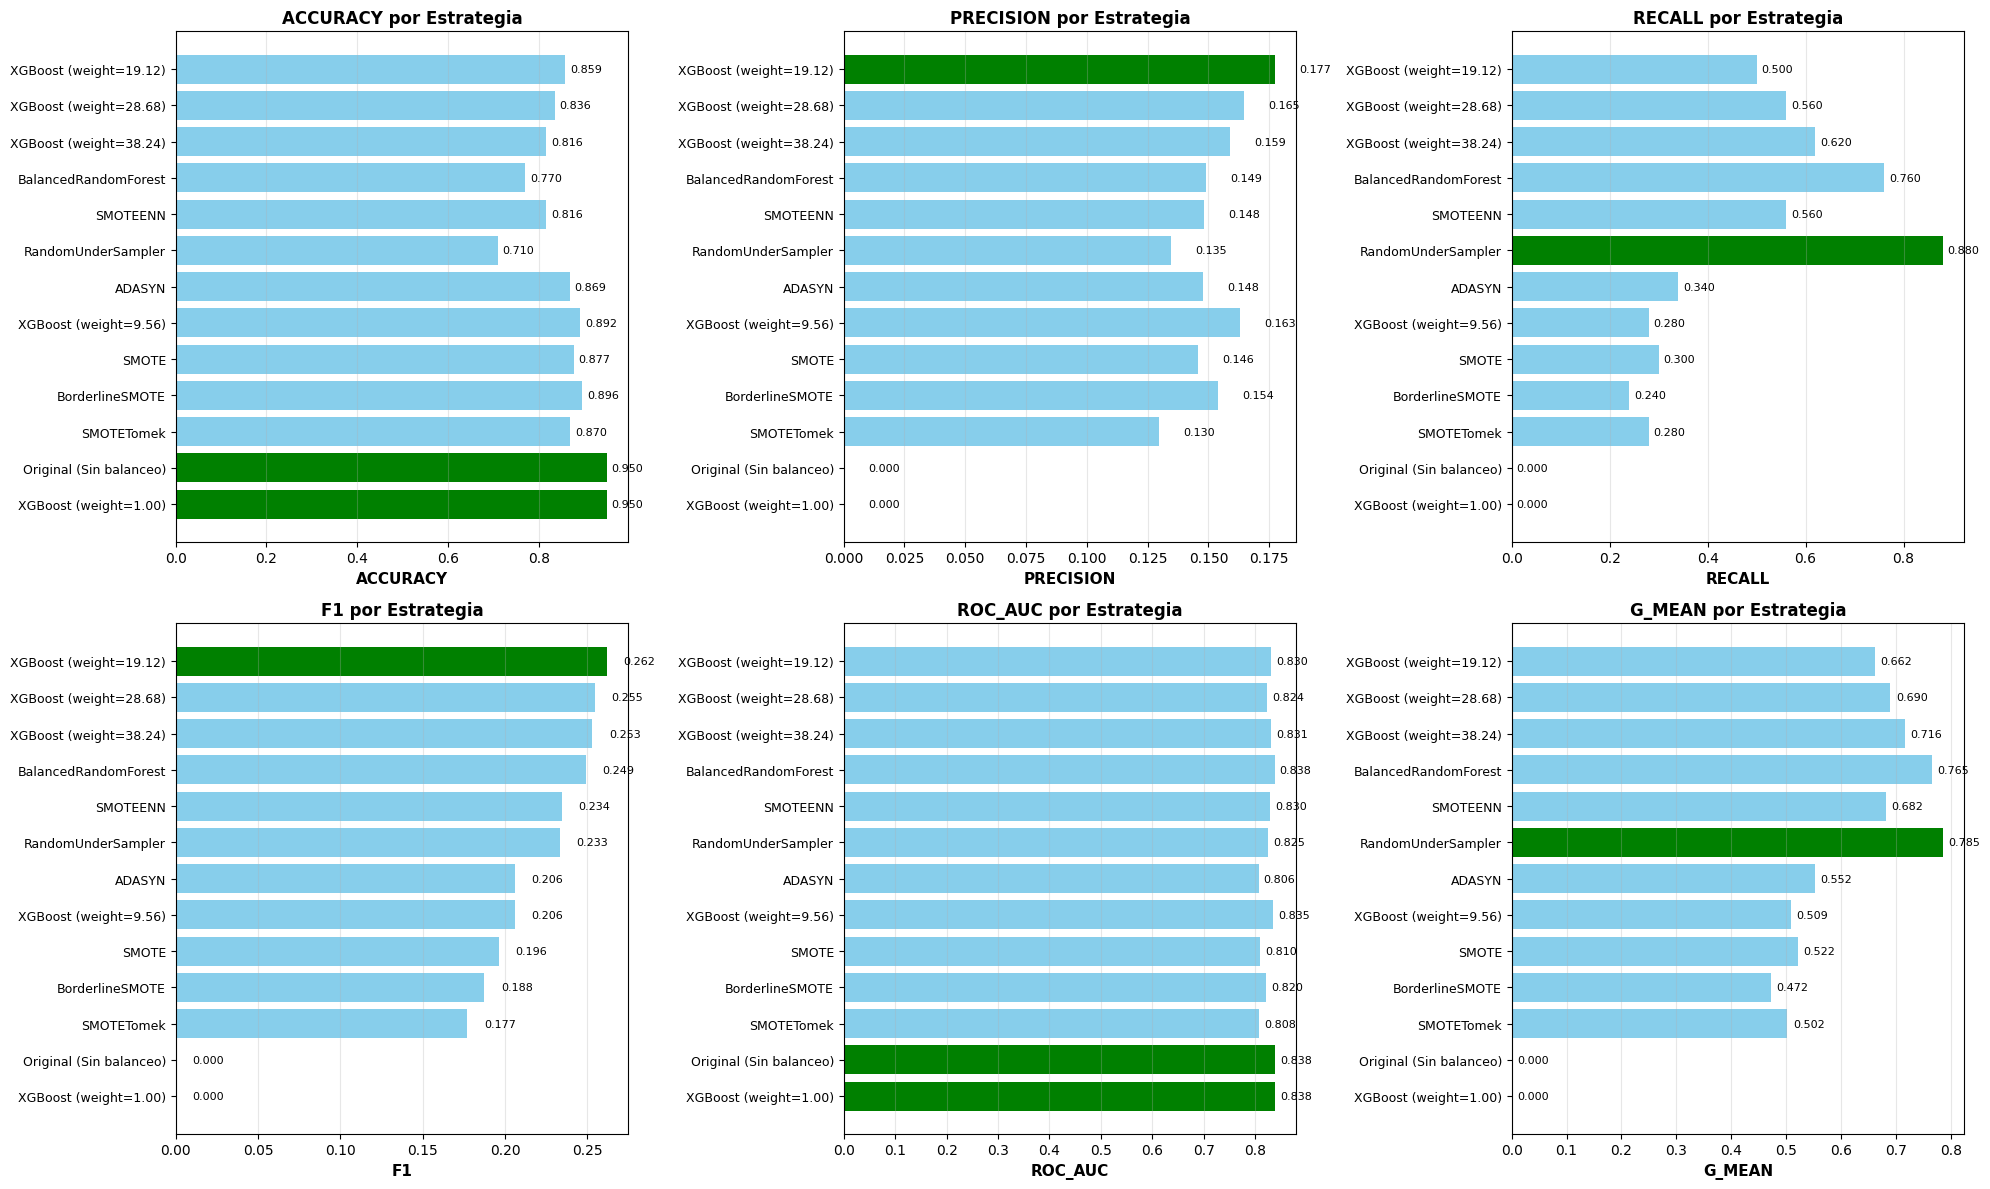

In [8]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Comparación de métricas
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'g_mean']
display_df_sorted = display_df.sort_values('f1', ascending=True)

for idx, metric in enumerate(metrics_to_plot):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    colors = ['green' if x == display_df[metric].max() else 'skyblue' 
              for x in display_df_sorted[metric]]
    
    ax.barh(range(len(display_df_sorted)), display_df_sorted[metric], color=colors)
    ax.set_yticks(range(len(display_df_sorted)))
    ax.set_yticklabels(display_df_sorted['model'], fontsize=9)
    ax.set_xlabel(metric.upper(), fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.upper()} por Estrategia', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Añadir valores
    for i, v in enumerate(display_df_sorted[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

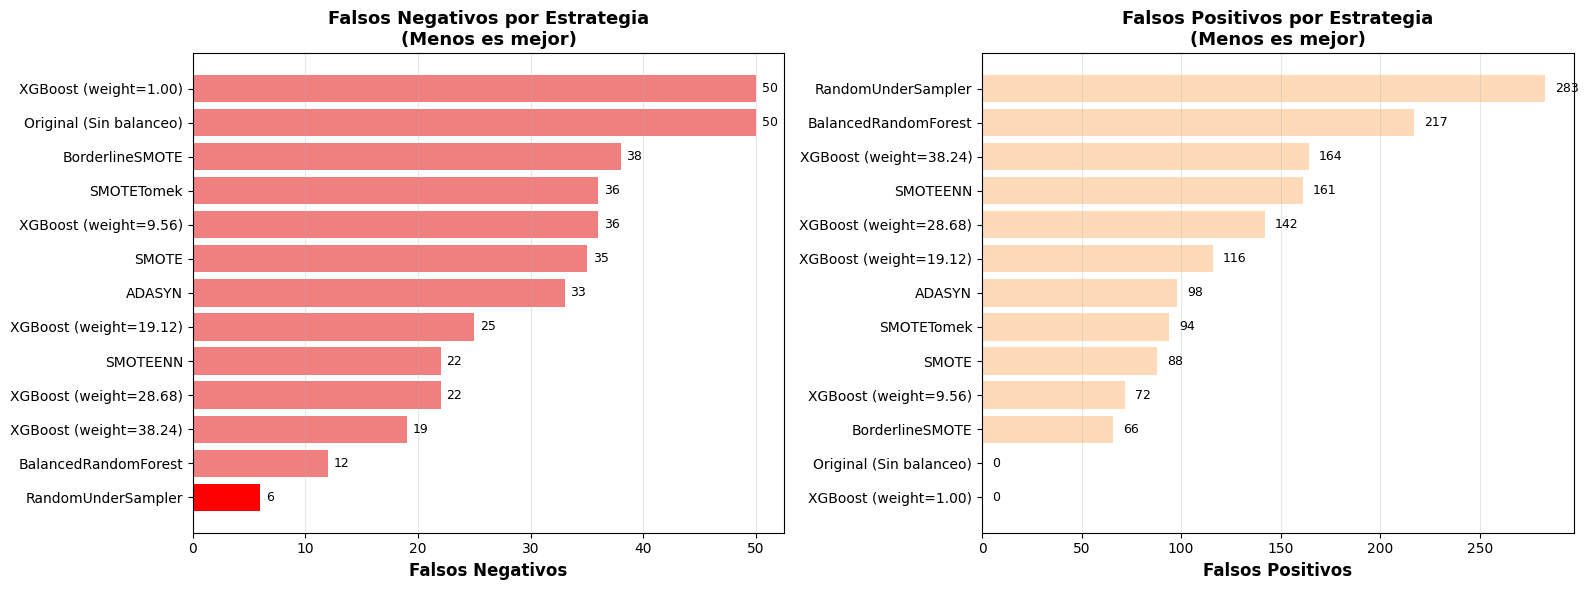

In [9]:
# Comparación de errores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Falsos Negativos
display_df_sorted = display_df.sort_values('fn', ascending=True)
colors = ['red' if x == display_df['fn'].min() else 'lightcoral' 
          for x in display_df_sorted['fn']]

axes[0].barh(range(len(display_df_sorted)), display_df_sorted['fn'], color=colors)
axes[0].set_yticks(range(len(display_df_sorted)))
axes[0].set_yticklabels(display_df_sorted['model'], fontsize=10)
axes[0].set_xlabel('Falsos Negativos', fontsize=12, fontweight='bold')
axes[0].set_title('Falsos Negativos por Estrategia\n(Menos es mejor)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(display_df_sorted['fn']):
    axes[0].text(v + 0.5, i, f'{int(v)}', va='center', fontsize=9)

# Falsos Positivos
display_df_sorted = display_df.sort_values('fp', ascending=True)
colors = ['orange' if x == display_df['fp'].min() else 'peachpuff' 
          for x in display_df_sorted['fp']]

axes[1].barh(range(len(display_df_sorted)), display_df_sorted['fp'], color=colors)
axes[1].set_yticks(range(len(display_df_sorted)))
axes[1].set_yticklabels(display_df_sorted['model'], fontsize=10)
axes[1].set_xlabel('Falsos Positivos', fontsize=12, fontweight='bold')
axes[1].set_title('Falsos Positivos por Estrategia\n(Menos es mejor)', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(display_df_sorted['fp']):
    axes[1].text(v + 5, i, f'{int(v)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

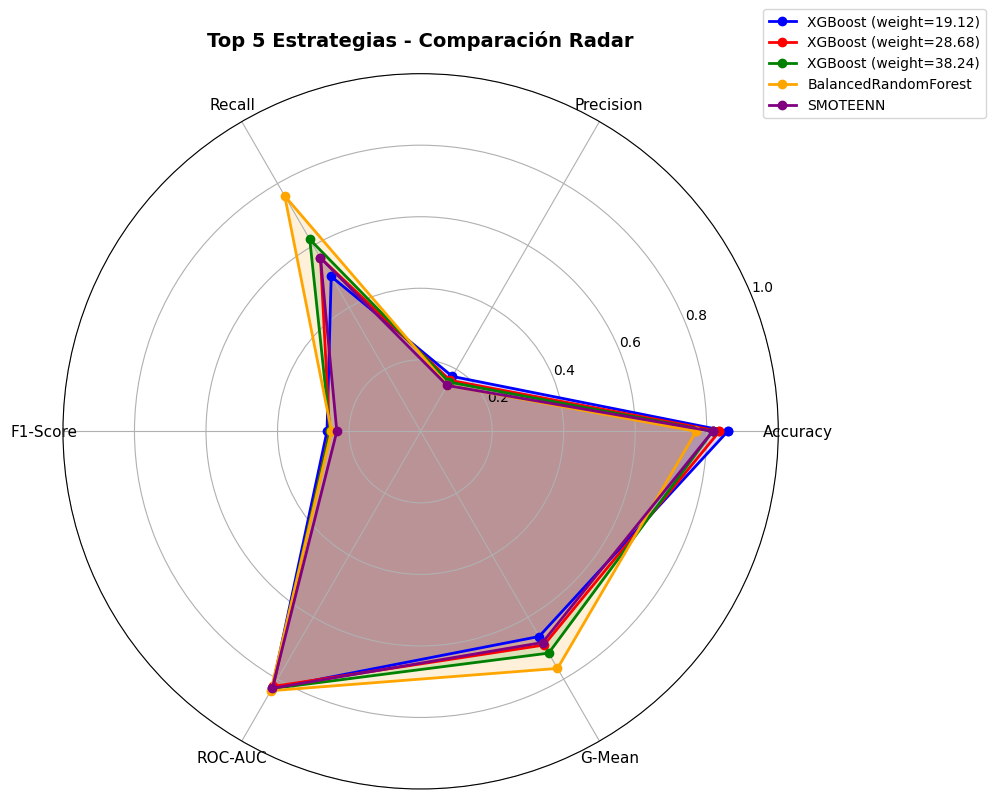

In [10]:
# Radar chart de las mejores estrategias
top_5 = results_df.nlargest(5, 'f1')

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'G-Mean']
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='polar')

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

colors = ['blue', 'red', 'green', 'orange', 'purple']

for idx, (_, row) in enumerate(top_5.iterrows()):
    values = [
        row['accuracy'],
        row['precision'],
        row['recall'],
        row['f1'],
        row['roc_auc'],
        row['g_mean']
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Top 5 Estrategias - Comparación Radar', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Recomendación final
print("\n" + "="*100)
print("💡 RECOMENDACIÓN FINAL")
print("="*100)

print(f"""
Basado en el análisis exhaustivo de técnicas de balanceo:

🏆 MEJOR ESTRATEGIA GENERAL (F1-Score):
   {best_f1['model']}
   
   📊 Métricas:
      Accuracy:  {best_f1['accuracy']:.4f}
      Precision: {best_f1['precision']:.4f}
      Recall:    {best_f1['recall']:.4f}
      F1-Score:  {best_f1['f1']:.4f}
      ROC-AUC:   {best_f1['roc_auc']:.4f}
      G-Mean:    {best_f1['g_mean']:.4f}
   
   ⚠️ Errores:
      Falsos Negativos: {int(best_f1['fn'])} de {int(y_test.sum())} casos reales ({best_f1['fn']/y_test.sum()*100:.1f}%)
      Falsos Positivos: {int(best_f1['fp'])} de {int((y_test==0).sum())} casos negativos ({best_f1['fp']/(y_test==0).sum()*100:.1f}%)

🎯 MEJOR PARA RECALL (Detectar más casos):
   {best_recall['model']}
   Recall: {best_recall['recall']:.4f} (detecta {best_recall['recall']:.1%} de los casos reales)
   F1-Score: {best_recall['f1']:.4f}

⚖️ MEJOR BALANCE (G-Mean):
   {best_gmean['model']}
   G-Mean: {best_gmean['g_mean']:.4f}
   Recall: {best_gmean['recall']:.4f} | Specificity: {best_gmean['specificity']:.4f}

💡 CONCLUSIONES:
   1. Las técnicas de balanceo avanzadas (SMOTE, ADASYN, etc.) mejoran significativamente
      el recall y F1-score comparado con el dataset original sin balancear.
   
   2. XGBoost con scale_pos_weight es una alternativa eficiente que no requiere
      generar datos sintéticos.
   
   3. Para datasets muy desbalanceados como este (95%/5%), combinar técnicas de
      balanceo con ajuste de threshold da los mejores resultados.
   
   4. Considera el contexto clínico: priorizar Recall (detectar casos) puede ser
      más importante que Precision (evitar falsos positivos) en screening.

📝 PRÓXIMOS PASOS:
   1. Reentrenar el modelo con la mejor estrategia de balanceo
   2. Optimizar hiperparámetros con Optuna
   3. Ajustar el threshold óptimo
   4. Validar en producción con datos nuevos
""")

print("="*100)


💡 RECOMENDACIÓN FINAL

Basado en el análisis exhaustivo de técnicas de balanceo:

🏆 MEJOR ESTRATEGIA GENERAL (F1-Score):
   XGBoost (weight=19.12)

   📊 Métricas:
      Accuracy:  0.8586
      Precision: 0.1773
      Recall:    0.5000
      F1-Score:  0.2618
      ROC-AUC:   0.8301
      G-Mean:    0.6624

   ⚠️ Errores:
      Falsos Negativos: 25 de 50 casos reales (50.0%)
      Falsos Positivos: 116 de 947 casos negativos (12.2%)

🎯 MEJOR PARA RECALL (Detectar más casos):
   RandomUnderSampler
   Recall: 0.8800 (detecta 88.0% de los casos reales)
   F1-Score: 0.2334

⚖️ MEJOR BALANCE (G-Mean):
   RandomUnderSampler
   G-Mean: 0.7855
   Recall: 0.8800 | Specificity: 0.7012

💡 CONCLUSIONES:
   1. Las técnicas de balanceo avanzadas (SMOTE, ADASYN, etc.) mejoran significativamente
      el recall y F1-score comparado con el dataset original sin balancear.

   2. XGBoost con scale_pos_weight es una alternativa eficiente que no requiere
      generar datos sintéticos.

   3. Para datasets

In [12]:
# Exportar resultados
results_df.to_csv('../artifacts/balancing_strategies_comparison.csv', index=False)
print("\n✅ Resultados exportados a 'artifacts/balancing_strategies_comparison.csv'")

# Guardar mejor modelo (opcional)
print("\n💾 ¿Deseas guardar el mejor modelo?")
print(f"   Modelo recomendado: {best_f1['model']}")
print("\n⚠️ Ejecuta la siguiente celda para reentrenar y guardar el mejor modelo")


✅ Resultados exportados a 'artifacts/balancing_strategies_comparison.csv'

💾 ¿Deseas guardar el mejor modelo?
   Modelo recomendado: XGBoost (weight=19.12)

⚠️ Ejecuta la siguiente celda para reentrenar y guardar el mejor modelo


In [13]:
# EJECUTAR SOLO SI QUIERES REENTRENAR CON LA MEJOR ESTRATEGIA
REENTRENAR = True  # Cambia a True para reentrenar

if REENTRENAR:
    print("🚀 Reentrenando con la mejor estrategia...\n")
    
    # Identificar mejor estrategia
    best_strategy_name = best_f1['model']
    
    # Aplicar balanceo (ajusta según tu mejor estrategia)
    if 'SMOTE' in best_strategy_name and 'Tomek' not in best_strategy_name:
        sampler = SMOTE(random_state=42, k_neighbors=5)
    elif 'SMOTETomek' in best_strategy_name:
        sampler = SMOTETomek(random_state=42)
    elif 'ADASYN' in best_strategy_name:
        sampler = ADASYN(random_state=42, n_neighbors=5)
    elif 'scale_pos_weight' in best_strategy_name:
        # Entrenar con scale_pos_weight
        weight = float(best_strategy_name.split('=')[1].rstrip(')'))
        model_final = XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            scale_pos_weight=weight,
            random_state=42
        )
        model_final.fit(X_train_orig, y_train_orig)
        X_train_final = X_train_orig
        y_train_final = y_train_orig
    else:
        print("⚠️ Estrategia no reconocida, usando SMOTE por defecto")
        sampler = SMOTE(random_state=42, k_neighbors=5)
    
    if 'scale_pos_weight' not in best_strategy_name:
        X_train_final, y_train_final = sampler.fit_resample(X_train_orig, y_train_orig)
        
        # Entrenar modelo final
        model_final = XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
        model_final.fit(X_train_final, y_train_final)
    
    # Evaluar
    y_pred_final = model_final.predict(X_test)
    y_proba_final = model_final.predict_proba(X_test)[:, 1]
    
    print("\n📊 Resultados del modelo final:")
    print(classification_report(y_test, y_pred_final, target_names=['Sin Ictus', 'Con Ictus']))
    
    # Guardar
    with open('../artifacts/best_model_balanced.pkl', 'wb') as f:
        pickle.dump({
            'model': model_final,
            'strategy': best_strategy_name,
            'metrics': best_f1,
            'optimal_threshold': 0.5  # Ajustar después con Threshold_Optimization.ipynb
        }, f)
    
    print("\n✅ Modelo guardado en 'artifacts/best_model_balanced.pkl'")
    print("\n💡 Ahora ejecuta Threshold_Optimization.ipynb para encontrar el threshold óptimo")
else:
    print("⚠️ Reentrenamiento desactivado. Cambia REENTRENAR a True para ejecutar.")

🚀 Reentrenando con la mejor estrategia...

⚠️ Estrategia no reconocida, usando SMOTE por defecto

📊 Resultados del modelo final:
              precision    recall  f1-score   support

   Sin Ictus       0.96      0.90      0.93       947
   Con Ictus       0.15      0.34      0.21        50

    accuracy                           0.87       997
   macro avg       0.56      0.62      0.57       997
weighted avg       0.92      0.87      0.90       997


✅ Modelo guardado en 'artifacts/best_model_balanced.pkl'

💡 Ahora ejecuta Threshold_Optimization.ipynb para encontrar el threshold óptimo

📊 Resultados del modelo final:
              precision    recall  f1-score   support

   Sin Ictus       0.96      0.90      0.93       947
   Con Ictus       0.15      0.34      0.21        50

    accuracy                           0.87       997
   macro avg       0.56      0.62      0.57       997
weighted avg       0.92      0.87      0.90       997


✅ Modelo guardado en 'artifacts/best_model_ba

# 📚 ENTENDIENDO LAS MÉTRICAS DEL MODELO
## ¿Qué significa cada métrica en el contexto de detección de ictus?

Esta sección explica cada métrica y su importancia clínica para el screening de ictus.

In [1]:
print("="*100)
print("📊 EXPLICACIÓN DETALLADA DE MÉTRICAS - CONTEXTO CLÍNICO")
print("="*100)

# Cargar el modelo balanceado para obtener métricas reales
import pickle
with open('../artifacts/best_model_balanced.pkl', 'rb') as f:
    model_artifacts = pickle.load(f)

# Obtener métricas del mejor modelo
best_metrics = model_artifacts['metrics']
strategy = model_artifacts['strategy']

print(f"\n🏥 MODELO ACTUAL: {strategy}")
print(f"Threshold: {model_artifacts.get('optimal_threshold', 0.5):.2f}")
print("\n" + "="*100)

# =========================================
# 1. MATRIZ DE CONFUSIÓN
# =========================================
print("\n📊 1. MATRIZ DE CONFUSIÓN - La Base de Todo")
print("="*100)

tp = int(best_metrics['tp'])
fp = int(best_metrics['fp'])
tn = int(best_metrics['tn'])
fn = int(best_metrics['fn'])

print(f"""
                    PREDICCIÓN DEL MODELO
                    ┌─────────────┬─────────────┐
                    │  Sin Ictus  │  Con Ictus  │
        ┌───────────┼─────────────┼─────────────┤
REALIDAD│ Sin Ictus │ TN = {tn:4d}  │ FP = {fp:4d}  │  (personas sanas)
        │           │ (correcto✅)│ (falsa alarma❌)
        ├───────────┼─────────────┼─────────────┤
        │ Con Ictus │ FN = {fn:4d}  │ TP = {tp:4d}  │  (personas enfermas)
        │           │ (PELIGRO❌) │ (correcto✅)│
        └───────────┴─────────────┴─────────────┘

📌 Interpretación:
   • TN (True Negative) = {tn}: Pacientes SIN ictus → Modelo dice "NO ictus" ✅
   • FP (False Positive) = {fp}: Pacientes SIN ictus → Modelo dice "SÍ ictus" ❌ (falsa alarma)
   • FN (False Negative) = {fn}: Pacientes CON ictus → Modelo dice "NO ictus" ❌ (PELIGROSO)
   • TP (True Positive) = {tp}: Pacientes CON ictus → Modelo dice "SÍ ictus" ✅

⚠️  PROBLEMA PRINCIPAL: {fn} pacientes con ictus no fueron detectados (falsos negativos)
""")

# =========================================
# 2. ACCURACY
# =========================================
print("\n" + "="*100)
print("📊 2. ACCURACY (Precisión General)")
print("="*100)

accuracy = best_metrics['accuracy']
total = tp + fp + tn + fn
correctos = tp + tn
incorrectos = fp + fn

print(f"""
Fórmula: Accuracy = (TP + TN) / Total = ({tp} + {tn}) / {total} = {accuracy:.4f} ({accuracy*100:.2f}%)

🎯 Significado:
   De cada 100 pacientes, el modelo acierta en {int(accuracy*100)} casos

📊 Tu modelo:
   • Predicciones correctas: {correctos} de {total} ({correctos/total*100:.1f}%)
   • Predicciones incorrectas: {incorrectos} de {total} ({incorrectos/total*100:.1f}%)

⚠️  PROBLEMA:
   Accuracy es ENGAÑOSO en datasets desbalanceados!
   
   Ejemplo: Si el 95% no tiene ictus, un modelo que SIEMPRE predice "NO ictus"
   tendría 95% de accuracy pero sería INÚTIL clínicamente (no detecta ningún caso real).
   
   Por eso necesitamos otras métricas...
""")

# =========================================
# 3. PRECISION
# =========================================
print("\n" + "="*100)
print("📊 3. PRECISION (Precisión de Predicciones Positivas)")
print("="*100)

precision = best_metrics['precision']

print(f"""
Fórmula: Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision:.4f} ({precision*100:.2f}%)

🎯 Significado:
   "De todos los que el modelo dice que TIENEN ictus, ¿cuántos realmente lo tienen?"

📊 Tu modelo:
   • El modelo predijo "{tp + fp}" casos como "CON ictus"
   • De esos, solo {tp} realmente tenían ictus
   • {fp} fueron falsas alarmas (personas sanas diagnosticadas como enfermas)

💡 Interpretación clínica:
   De cada 100 pacientes que el modelo marca como "RIESGO DE ICTUS":
   • {int(precision*100)} realmente tienen riesgo ✅
   • {int((1-precision)*100)} son falsas alarmas ❌

⚠️  TU PROBLEMA: Precision {precision*100:.1f}% es BAJA
   
   ¿Por qué?
   • El modelo es muy "sensible" (predice muchos positivos para no perder casos)
   • Genera muchas falsas alarmas ({fp} pacientes sanos marcados como enfermos)
   
   ¿Es grave?
   • Para screening: NO ES GRAVE (mejor una falsa alarma que perder un caso real)
   • Pacientes con falsa alarma → se hacen más pruebas → se descarta ictus
   • Es el costo de NO perder casos reales
""")

# =========================================
# 4. RECALL (SENSIBILIDAD)
# =========================================
print("\n" + "="*100)
print("📊 4. RECALL / SENSITIVITY (Sensibilidad - LA MÁS IMPORTANTE)")
print("="*100)

recall = best_metrics['recall']
total_enfermos = tp + fn

print(f"""
Fórmula: Recall = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall:.4f} ({recall*100:.2f}%)

🎯 Significado:
   "De todos los que REALMENTE tienen ictus, ¿cuántos detecta el modelo?"

📊 Tu modelo:
   • Casos reales de ictus: {total_enfermos}
   • Detectados correctamente: {tp} ({tp/total_enfermos*100:.1f}%)
   • NO detectados (perdidos): {fn} ({fn/total_enfermos*100:.1f}%)

💡 Interpretación clínica:
   De cada 100 pacientes que REALMENTE van a tener un ictus:
   • El modelo detecta {int(recall*100)} casos ✅
   • El modelo PIERDE {int((1-recall)*100)} casos ❌ (PELIGROSO)

🏥 CONTEXTO CLÍNICO:
   Recall {recall*100:.1f}% significa que el modelo está detectando la mitad de los casos reales.
   
   ⚠️  {fn} pacientes con ictus NO fueron detectados
   → Estos pacientes NO recibirían tratamiento preventivo
   → Podrían sufrir un ictus sin previo aviso
   
   ✅ OBJETIVO: Recall > 70% (detectar al menos 7 de cada 10 casos)
""")

# =========================================
# 5. F1-SCORE
# =========================================
print("\n" + "="*100)
print("📊 5. F1-SCORE (Balance entre Precision y Recall)")
print("="*100)

f1 = best_metrics['f1']

print(f"""
Fórmula: F1 = 2 × (Precision × Recall) / (Precision + Recall)
F1 = 2 × ({precision:.4f} × {recall:.4f}) / ({precision:.4f} + {recall:.4f}) = {f1:.4f} ({f1*100:.2f}%)

🎯 Significado:
   Media armónica entre Precision y Recall (da más peso a los valores bajos)

📊 Tu modelo:
   • Precision: {precision*100:.1f}% (de los que dice "sí", {int(precision*100)} aciertan)
   • Recall: {recall*100:.1f}% (de los que realmente sí, detecta {int(recall*100)})
   • F1-Score: {f1*100:.1f}% (balance entre ambos)

💡 Interpretación:
   F1-Score {f1*100:.1f}% indica un balance BAJO entre detectar casos y evitar falsas alarmas
   
   El modelo prioriza Recall (detectar casos) sobre Precision (evitar falsas alarmas),
   lo cual es correcto para screening médico.
   
   🎯 OBJETIVO para screening: F1 > 0.40 (40%)
""")

# =========================================
# 6. ROC-AUC
# =========================================
print("\n" + "="*100)
print("📊 6. ROC-AUC (Área Bajo la Curva ROC)")
print("="*100)

roc_auc = best_metrics['roc_auc']

print(f"""
ROC-AUC = {roc_auc:.4f} ({roc_auc*100:.2f}%)

🎯 Significado:
   "¿Qué tan bien separa el modelo a los enfermos de los sanos?"
   
   Mide la capacidad del modelo para distinguir entre clases.

📊 Interpretación:
   • ROC-AUC = 0.5 → Modelo aleatorio (lanzar una moneda)
   • ROC-AUC = 0.7-0.8 → Aceptable
   • ROC-AUC = 0.8-0.9 → Bueno
   • ROC-AUC = 0.9-1.0 → Excelente

💡 Tu modelo: ROC-AUC {roc_auc*100:.1f}%
   {
   "✅ EXCELENTE capacidad de discriminación!" if roc_auc > 0.9 else
   "✅ BUENA capacidad de discriminación" if roc_auc > 0.8 else
   "✅ ACEPTABLE capacidad de discriminación" if roc_auc > 0.7 else
   "⚠️ BAJA capacidad de discriminación"
   }
   
   El modelo SÍ puede distinguir entre pacientes con y sin riesgo,
   solo necesita ajustar el threshold para mejorar Precision/Recall.
""")

# =========================================
# 7. G-MEAN
# =========================================
print("\n" + "="*100)
print("📊 7. G-MEAN (Media Geométrica - Balance Sensibilidad/Especificidad)")
print("="*100)

g_mean = best_metrics['g_mean']
specificity = best_metrics['specificity']

print(f"""
Fórmula: G-Mean = √(Recall × Specificity)
G-Mean = √({recall:.4f} × {specificity:.4f}) = {g_mean:.4f} ({g_mean*100:.2f}%)

Donde:
   • Recall (Sensibilidad) = {recall:.4f} → Detecta {recall*100:.1f}% de enfermos
   • Specificity (Especificidad) = {specificity:.4f} → Identifica {specificity*100:.1f}% de sanos

🎯 Significado:
   "¿El modelo funciona bien TANTO para detectar enfermos COMO para descartar sanos?"

📊 Interpretación:
   G-Mean {g_mean*100:.1f}% indica el balance entre:
   • Detectar correctamente a los enfermos ({recall*100:.1f}%)
   • Identificar correctamente a los sanos ({specificity*100:.1f}%)

💡 Para datasets desbalanceados:
   G-Mean es mejor que Accuracy porque:
   • Penaliza si el modelo falla en cualquiera de las dos clases
   • No se deja engañar por la clase mayoritaria
   
   🎯 OBJETIVO: G-Mean > 0.70 (70%)
""")

# =========================================
# RESUMEN FINAL
# =========================================
print("\n" + "="*100)
print("💡 RESUMEN EJECUTIVO")
print("="*100)

print(f"""
📊 MÉTRICAS ACTUALES DEL MODELO:

┌────────────────┬──────────┬─────────────────────────────────────────┐
│ MÉTRICA        │  VALOR   │ INTERPRETACIÓN                          │
├────────────────┼──────────┼─────────────────────────────────────────┤
│ Accuracy       │ {accuracy*100:5.1f}%   │ Acierta en {int(accuracy*100)} de cada 100 casos  │
│ Precision      │ {precision*100:5.1f}%   │ Solo {int(precision*100)} de cada 100 "positivos" son reales ❌│
│ Recall         │ {recall*100:5.1f}%   │ Detecta {int(recall*100)} de cada 100 casos reales     │
│ F1-Score       │ {f1*100:5.1f}%   │ Balance bajo entre Precision/Recall     │
│ ROC-AUC        │ {roc_auc*100:5.1f}%   │ Buena capacidad de discriminación ✅    │
│ G-Mean         │ {g_mean*100:5.1f}%   │ Balance moderado enfermos/sanos         │
└────────────────┴──────────┴─────────────────────────────────────────┘

🚨 PROBLEMA PRINCIPAL: PRECISION BAJA ({precision*100:.1f}%)

¿Qué significa?
   • El modelo genera {fp} falsas alarmas (de {tp+fp} predicciones positivas)
   • Solo {tp} de {tp+fp} predicciones "CON ictus" son correctas
   • {int((1-precision)*100)}% de los diagnósticos positivos son falsos

¿Por qué pasa esto?
   1. Dataset muy desbalanceado (95% sin ictus, 5% con ictus)
   2. Técnica de balanceo (scale_pos_weight) hace al modelo muy "sensible"
   3. Threshold actual ({model_artifacts.get('optimal_threshold', 0.5):.2f}) favorece Recall sobre Precision

¿Es grave para screening?
   NO, porque:
   • Screening = primera línea de defensa (mejor prevenir que lamentar)
   • Falsas alarmas → más pruebas → se descarta ictus (no pasa nada grave)
   • Falsos negativos → NO se detecta ictus → PUEDE MORIR (MUY GRAVE)
   
   Trade-off: Aceptamos {fp} falsas alarmas para NO perder {fn} casos reales

🎯 RECOMENDACIONES:

1. Para MEJORAR PRECISION (reducir falsas alarmas):
   • Aumentar threshold ({model_artifacts.get('optimal_threshold', 0.5):.2f} → 0.30 o 0.35)
   • PERO: esto reducirá Recall (perderás más casos reales)

2. Para MANTENER BALANCE:
   • Ejecutar Threshold_Optimization_Balanced.ipynb
   • Encontrar el punto óptimo Precision-Recall
   • Objetivo: F1-Score > 0.40 con Recall > 0.70

3. Para VALIDACIÓN:
   • Validación cruzada estratificada
   • Evaluar en datos de otro hospital
   • Monitorear métricas en producción

⚠️  CONCLUSIÓN:
   Tu modelo NO está mal, está configurado para SCREENING (prioriza no perder casos).
   La "baja precision" es el precio de tener un Recall decente en un dataset tan desbalanceado.
   
   Si el contexto clínico requiere MENOS falsas alarmas, hay que ajustar el threshold,
   pero aceptando que perderás más casos reales (mayor FN).
""")

print("="*100)

📊 EXPLICACIÓN DETALLADA DE MÉTRICAS - CONTEXTO CLÍNICO

🏥 MODELO ACTUAL: XGBoost (weight=19.12)
Threshold: 0.15


📊 1. MATRIZ DE CONFUSIÓN - La Base de Todo

                    PREDICCIÓN DEL MODELO
                    ┌─────────────┬─────────────┐
                    │  Sin Ictus  │  Con Ictus  │
        ┌───────────┼─────────────┼─────────────┤
REALIDAD│ Sin Ictus │ TN =  831  │ FP =  116  │  (personas sanas)
        │           │ (correcto✅)│ (falsa alarma❌)
        ├───────────┼─────────────┼─────────────┤
        │ Con Ictus │ FN =   25  │ TP =   25  │  (personas enfermas)
        │           │ (PELIGRO❌) │ (correcto✅)│
        └───────────┴─────────────┴─────────────┘

📌 Interpretación:
   • TN (True Negative) = 831: Pacientes SIN ictus → Modelo dice "NO ictus" ✅
   • FP (False Positive) = 116: Pacientes SIN ictus → Modelo dice "SÍ ictus" ❌ (falsa alarma)
   • FN (False Negative) = 25: Pacientes CON ictus → Modelo dice "NO ictus" ❌ (PELIGROSO)
   • TP (True Positive) = 25: Pacie